In [234]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [235]:
file_path="C:/Users/USER/Desktop/geopolymar/GPC_Dataset_f.csv"
df=pd.read_csv(file_path)
df = df.drop(["Unnamed: 14","Unnamed: 15"], axis=1)
df = df.dropna()
df.head()

,FA/binder,CA/Binder,Binder (kg),% of SiO2,% of CaO,% of Al2O3,liquid/binder ratio,NaOH Molarity,Na2SiO3/ NaOH,Additional Water (%),SP (% of b),Curing temp (0 C),Age,Comp. Strength (Mpa)
0,2.11,2.33,360.0,92.21,0.51,0.38,0.5,10.0,1.0,0.0,1.0,23.0,3.0,19.14
1,2.11,2.33,360.0,92.21,0.51,0.38,0.5,10.0,1.0,0.0,1.0,23.0,7.0,22.88
2,2.11,2.33,360.0,92.21,0.51,0.38,0.5,10.0,1.0,0.0,1.0,23.0,14.0,24.53
3,2.11,2.33,360.0,92.21,0.51,0.38,0.5,10.0,1.0,0.0,1.0,23.0,28.0,25.41
4,2.12,2.34,360.0,61.00,2.64,22.83,0.5,10.0,1.0,0.0,1.0,23.0,3.0,8.03


In [236]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [237]:


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)


In [238]:

model = Sequential([
    layers.Input(shape=(X_train.shape[1],)), 
    # Switched to 'tanh' for smoother gradients (better for PINN transition)
    layers.Dense(64, activation='tanh'),      
    layers.Dense(32, activation='tanh'),      
    layers.Dense(1)                           
])


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Optional: Add this to your fit function to stop when the model is at its best
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("Training started...")
model.fit(X_train_scaled, y_train_scaled, 
          epochs=500, # Increased
          validation_split=0.1, # Added to monitor performance
          callbacks=[early_stop], 
          verbose=0)

Training started...


In [239]:
# 5. Predictions and Metrics
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform to get real MPa
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_scaled)

# 6. Calculate Final Metrics

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step 


In [240]:
sample = X_test[0:1]
prediction_scaled = model.predict(sample)

# Convert back from 0-1 range to real MPa
actual_prediction = scaler_y.inverse_transform(prediction_scaled)
actual_value = scaler_y.inverse_transform(y_test[0:1])

print(f"Predicted Strength: {actual_prediction[0][0]:.2f} MPa")
print(f"Actual Strength: {actual_value[0][0]:.2f} MPa")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Predicted Strength: 63.08 MPa
Actual Strength: 487.34 MPa


In [241]:
print(y_actual.shape)
print(y_pred.shape)


(204, 1)
(204, 1)


In [242]:
# 6. Calculate Final Metrics
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("\n--- Final Performance ---")
print(f"MAE: {mae:.4f} MPa")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")


--- Final Performance ---
MAE: 4.9755 MPa
MSE: 39.1287
R2 Score: 0.8510


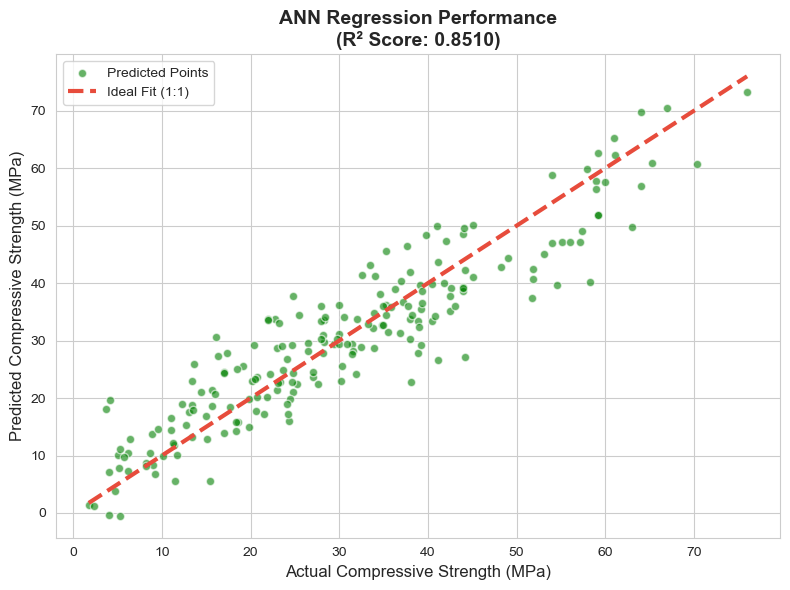

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# 1. Create the scatter plot
plt.scatter(y_actual, y_pred, alpha=0.6, edgecolors='w', color='green', label='Predicted Points')

# 2. Create the "Perfect Prediction" line (45-degree line)
# We find the min and max values of the actual data to draw the line
line_range = [y_actual.min(), y_actual.max()]
plt.plot(line_range, line_range, color='#e74c3c', linestyle='--', lw=3, label='Ideal Fit (1:1)')

# 3. Add Labels and Title
plt.xlabel('Actual Compressive Strength (MPa)', fontsize=12)
plt.ylabel('Predicted Compressive Strength (MPa)', fontsize=12)
plt.title(f'ANN Regression Performance\n(R² Score: {r2:.4f})', fontsize=14, fontweight='bold')

# 4. Add a legend and grid
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [244]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# 1. DATA PREPARATION
file_path = "C:/Users/USER/Desktop/geopolymar/GPC_Dataset_f.csv"
df = pd.read_csv(file_path).drop(["Unnamed: 14","Unnamed: 15"], axis=1).dropna()

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = tf.cast(scaler_X.fit_transform(X_train), tf.float32)
X_test_scaled = tf.cast(scaler_X.transform(X_test), tf.float32)
y_train_scaled = tf.cast(scaler_y.fit_transform(y_train), tf.float32)
y_test_scaled = tf.cast(scaler_y.transform(y_test), tf.float32)

# 2. PINN MODEL (Using 'tanh' for smooth derivatives)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(32, activation='tanh'),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# 3. THE PINN LOSS FUNCTION
def compute_loss(X_batch, y_batch, physics_weight=0.1):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(X_batch)
        y_pred = model(X_batch)
        
        # A. Data Loss (MSE)
        data_loss = tf.reduce_mean(tf.square(y_batch - y_pred))
        
        # B. Physics Loss (Gradients)
        grads = tape.gradient(y_pred, X_batch)
        
        # Index 10: Curing Temp | Index 11: Age
        d_strength_d_temp = grads[:, 10]
        d_strength_d_age = grads[:, 11]
        
        # Penalize if derivative is negative (Strength should not drop when Temp or Age increases)
        physics_loss_temp = tf.reduce_mean(tf.square(tf.minimum(d_strength_d_temp, 0.0)))
        physics_loss_age = tf.reduce_mean(tf.square(tf.minimum(d_strength_d_age, 0.0)))
        
        total_physics_loss = physics_loss_temp + physics_loss_age
        total_loss = data_loss + (physics_weight * total_physics_loss)
        
    # Update Weights
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, data_loss, total_physics_loss

# 4. TRAINING LOOP
epochs = 200
batch_size = 32

print("Starting PINN Training...")
for epoch in range(epochs):
    # Simple batching
    indices = np.random.permutation(len(X_train_scaled))
    X_shuffled = tf.gather(X_train_scaled, indices)
    y_shuffled = tf.gather(y_train_scaled, indices)
    
    for i in range(0, len(X_train_scaled), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        loss, d_loss, p_loss = compute_loss(X_batch, y_batch)
        
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Total Loss: {loss:.4f} | Data Loss: {d_loss:.4f} | Physics Loss: {p_loss:.4f}")

# 5. EVALUATION
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_scaled)

print(f"\nPINN R2 Score: {r2_score(y_actual, y_pred):.4f}")
print(f"PINN MAE: {mean_absolute_error(y_actual, y_pred):.4f} MPa")

Starting PINN Training...
Epoch 0: Total Loss: 0.5760 | Data Loss: 0.5740 | Physics Loss: 0.0197
Epoch 20: Total Loss: 0.1349 | Data Loss: 0.1289 | Physics Loss: 0.0595
Epoch 40: Total Loss: 0.1407 | Data Loss: 0.1363 | Physics Loss: 0.0441
Epoch 60: Total Loss: 0.0718 | Data Loss: 0.0689 | Physics Loss: 0.0292
Epoch 80: Total Loss: 0.1318 | Data Loss: 0.1305 | Physics Loss: 0.0130
Epoch 100: Total Loss: 0.0849 | Data Loss: 0.0800 | Physics Loss: 0.0492
Epoch 120: Total Loss: 0.1963 | Data Loss: 0.1956 | Physics Loss: 0.0077
Epoch 140: Total Loss: 0.0699 | Data Loss: 0.0685 | Physics Loss: 0.0135
Epoch 160: Total Loss: 0.0416 | Data Loss: 0.0384 | Physics Loss: 0.0320
Epoch 180: Total Loss: 0.1500 | Data Loss: 0.1476 | Physics Loss: 0.0241
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step 

PINN R2 Score: 0.8889
PINN MAE: 4.1241 MPa
